**<h1>Project-9: Throughput Prediction in a Dense 5G deployment with Vertical FL</h1>**

**<h2>Group-H</h2>**
* hirdesh.kumar@mail.polimi.it
* hammad.syarif@mail.polimi.it
* zahrasadat.parviss@mail.polimi.it

---



## **1: Setup and Config**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy.spatial import KDTree

In [2]:
pwd

'/kaggle/working'

In [3]:
dataset_mount_path="/kaggle/input/datasets/hirdeshkumar240798/l5ghdd-dataset/L5GHDD_Dataset/L5GHDD_Dataset"

os.chdir(dataset_mount_path)
os.listdir()

['ACC_Arena', 'Salt_Tar']

In [4]:
# import os

# Assuming DATASET_PATH is defined in a previous cell as '/content/drive/MyDrive/ColabNotebooks/NMDA2/Project/L5GHDD_Dataset'

#print(f"User query: 'the notebook is made first 500 users and lets try include rest 12000 users'")
#print(f"To include data for all 12000 users, we need to process files for User IDs from 0 to 11999.")
#print(f"These are typically split into chunks of 500 users per file.")

# User updated: 'ram is crashing  lets try with 12000 users', then KeyboardInterrupt
# Further reducing max_user_id from 5999 to 999 to process 1000 users (0-999)
max_user_id = 11999
chunk_size = 500

# List of subdirectories containing the metric files
data_subdirs = {
    "Positions": "ACC_Arena/Positions_Acc_Arena/",
    "Throughput": "ACC_Arena/Throughput_Acc_Arena/",
    "SINR": "ACC_Arena/SINR_Acc_Arena/",
    "PRB": "ACC_Arena/PRB_Acc_Arena/",
    "RU": "ACC_Arena/RU_Association_Acc_Arena/",
    "BLER": "ACC_Arena/BLER_Acc_Arena/"
}

# Base filename patterns for each metric, extracted from the notebook's existing loading logic
file_patterns = {
    "Positions": "Positions_Salt_Tar_UE_Id_",
    "Throughput": "Throughput_UE_Id_",
    "SINR": "SINRUL_UE_Id_",
    "PRB": "PRBS_UE_Id_",
    "RU": "RU_UE_Id_",
    "BLER": "BLER_UE_Id_"
}

all_files_to_process = []

for metric_name, subdir in data_subdirs.items():
    print(f"\n--- Listing {metric_name} files in {subdir} ---")
    for start_id in range(0, max_user_id + 1, chunk_size):
        end_id = start_id + chunk_size - 1
        if end_id > max_user_id:
            end_id = max_user_id

        filename_prefix = file_patterns[metric_name]
        filename = f"{filename_prefix}{start_id}_{end_id}.csv"

        # Paths are relative to DATASET_PATH because os.chdir(DATASET_PATH) was called in an earlier cell.
        expected_file_path = os.path.join(subdir, filename)
        all_files_to_process.append(expected_file_path)
        print(expected_file_path)

print(f"\nIn total, {len(all_files_to_process)} files are expected to be processed for all {max_user_id + 1} users.")
print(f"The next step would involve modifying cells that load data (e.g., cell `fp3mSLPLAj2h` and `dyWc1dl6GqgQ`)")
print(f"to iterate through these file patterns and concatenate the resulting dataframes.")


--- Listing Positions files in ACC_Arena/Positions_Acc_Arena/ ---
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_0_499.csv
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_500_999.csv
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_1000_1499.csv
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_1500_1999.csv
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_2000_2499.csv
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_2500_2999.csv
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_3000_3499.csv
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_3500_3999.csv
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_4000_4499.csv
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_4500_4999.csv
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_5000_5499.csv
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_5500_5999.csv
ACC_Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_6000_6499.csv
ACC_Arena/Positions_Acc_Arena/Positions_Sa

## **2: Data Preprocessing**

For the inital phase, we are cosidering 500 user from ACC out of 3000.

###**2.1: Dataset Cleaning and Construction**

This cell handles standard files `(Throughput, SINR, PRB, RU, BLER)` by melting them and stripping out the *entityStats id* text so we are left with pure integers.

In [5]:
def flatten_metric(file_path, feature_name):
    # Load the  CSV
    df = pd.read_csv(file_path)

    # Melt using 'time' as the anchor
    df_long = df.melt(id_vars=['time'], var_name='User_String', value_name=feature_name)

    # Clean the columns: rename 'time' to 'Timestamp'
    df_long.rename(columns={'time': 'Timestamp'}, inplace=True)

    # Strip "entityStats id " from the string to get the pure integer ID
    df_long['User_ID'] = df_long['User_String'].str.replace('entityStats id ', '').astype('int32')

    # Drop the old string column and return
    return df_long[['Timestamp', 'User_ID', feature_name]]

In [6]:
import pandas as pd
import numpy as np
import os
import gc  # Garbage collector to aggressively free RAM

# ==========================================
# 1. GLOBAL SETTINGS & FUNCTIONS
# ==========================================
DATASET_PATH = dataset_mount_path  # Ensure this variable is active in your notebook
max_user_id = 11999                 # 12,000 users total (0-11999)
chunk_size = 500

def flatten_metric(file_path, feature_name):
    df = pd.read_csv(file_path)
    df_long = df.melt(id_vars=['time'], var_name='User_String', value_name=feature_name)
    df_long.rename(columns={'time': 'Timestamp'}, inplace=True)
    df_long['User_ID'] = df_long['User_String'].str.replace('entityStats id ', '').astype('int32')
    return df_long[['Timestamp', 'User_ID', feature_name]]

agg_rules = {
    'Throughput': 'max',
    'PRB': 'max',
    'Latitude': 'mean',
    'Longitude': 'mean',
    'Altitude': 'mean',
    'X_meters': 'mean',
    'Y_meters': 'mean',
    'SINR_UL': 'mean',
    'BLER': 'mean',
    'RU': 'first',
    'MobileState': 'first'
}

aggregated_chunks = []
global_origin_lat = None
global_origin_lon = None

print(f"🚀 Starting ultra-lean ingestion for {max_user_id + 1} users...")

# ==========================================
# 2. THE ISOLATED CHUNK LOOP
# ==========================================
for start_id in range(0, max_user_id + 1, chunk_size):
    end_id = min(start_id + chunk_size - 1, max_user_id)
        
    print(f"🔄 Processing file chunk: Users {start_id} to {end_id}...")
    
    # Construct exact file paths for this single chunk
    tp_path   = os.path.join(DATASET_PATH, "ACC_Arena/Throughput_Acc_Arena", f"Throughput_UE_Id_{start_id}_{end_id}.csv")
    sinr_path = os.path.join(DATASET_PATH, "ACC_Arena/SINR_Acc_Arena", f"SINRUL_UE_Id_{start_id}_{end_id}.csv")
    prb_path  = os.path.join(DATASET_PATH, "ACC_Arena/PRB_Acc_Arena", f"PRBS_UE_Id_{start_id}_{end_id}.csv")
    ru_path   = os.path.join(DATASET_PATH, "ACC_Arena/RU_Association_Acc_Arena", f"RU_UE_Id_{start_id}_{end_id}.csv")
    bler_path = os.path.join(DATASET_PATH, "ACC_Arena/BLER_Acc_Arena", f"BLER_UE_Id_{start_id}_{end_id}.csv")
    pos_path  = os.path.join(DATASET_PATH, "ACC_Arena/Positions_Acc_Arena", f"Positions_Salt_Tar_UE_Id_{start_id}_{end_id}.csv")
    
    # Flatten metrics (Removing duplicates instantly to save space)
    tp_c   = flatten_metric(tp_path, "Throughput").drop_duplicates(subset=['Timestamp', 'User_ID'])
    sinr_c = flatten_metric(sinr_path, "SINR_UL").drop_duplicates(subset=['Timestamp', 'User_ID'])
    prb_c  = flatten_metric(prb_path, "PRB").drop_duplicates(subset=['Timestamp', 'User_ID'])
    ru_c   = flatten_metric(ru_path, "RU").drop_duplicates(subset=['Timestamp', 'User_ID'])
    bler_c = flatten_metric(bler_path, "BLER").drop_duplicates(subset=['Timestamp', 'User_ID'])
    
    # Process Positions Matrix safely
    df_pos_raw = pd.read_csv(pos_path)
    raw_matrix = df_pos_raw.values
    timestamps = raw_matrix[:, 0]
    data_matrix = raw_matrix[:, 1:]
    num_timestamps = len(timestamps)
    num_users_in_chunk = end_id - start_id + 1
    
    reshaped_pos = data_matrix.reshape(num_timestamps, num_users_in_chunk, 5)
    records = []
    for t_idx in range(num_timestamps):
        t_val = int(timestamps[t_idx])
        for u_idx in range(num_users_in_chunk):
            u_id, lat, lon, alt, state = reshaped_pos[t_idx, u_idx]
            records.append([t_val, int(u_id), lat, lon, alt, int(state)])
            
    pos_c = pd.DataFrame(records, columns=['Timestamp', 'User_ID', 'Latitude', 'Longitude', 'Altitude', 'MobileState'])
    
    # Set Global Origin ONLY on the very first chunk so the whole stadium aligns perfectly
    if global_origin_lat is None:
        global_origin_lat = pos_c['Latitude'].iloc[0]
        global_origin_lon = pos_c['Longitude'].iloc[0]
        LAT_TO_M = 111320.0
        LON_TO_M = 111320.0 * np.cos(np.radians(global_origin_lat))
    
    # Calculate Cartesian Meters based on the Global Origin
    pos_c['X_meters'] = (pos_c['Longitude'] - global_origin_lon) * LON_TO_M
    pos_c['Y_meters'] = (pos_c['Latitude'] - global_origin_lat) * LAT_TO_M
    pos_c = pos_c.drop_duplicates(subset=['Timestamp', 'User_ID'])
    
    # Inner Merge all metrics for this chunk
    chunk_df = pos_c.merge(tp_c,   on=['Timestamp', 'User_ID'], how='inner') \
                     .merge(sinr_c, on=['Timestamp', 'User_ID'], how='inner') \
                     .merge(prb_c,  on=['Timestamp', 'User_ID'], how='inner') \
                     .merge(ru_c,   on=['Timestamp', 'User_ID'], how='inner') \
                     .merge(bler_c, on=['Timestamp', 'User_ID'], how='inner')
    
    # ==========================================
    # 3. INSTANT 15-SECOND AGGREGATION
    # ==========================================
    chunk_df['Timestamp_DT'] = pd.to_datetime(chunk_df['Timestamp'], unit='s')
    chunk_agg = (chunk_df.set_index('Timestamp_DT')
                         .groupby('User_ID')
                         .resample('15S')
                         .agg(agg_rules)
                         .dropna()
                         .reset_index())
    
    # Downcast datatypes to lock down memory usage
    float32_cols = ['Latitude', 'Longitude', 'Altitude', 'X_meters', 'Y_meters', 'Throughput', 'SINR_UL', 'PRB', 'BLER']
    chunk_agg[float32_cols] = chunk_agg[float32_cols].astype('float32')
    chunk_agg['User_ID'] = chunk_agg['User_ID'].astype('int32')
    chunk_agg['RU'] = chunk_agg['RU'].astype('int8')
    chunk_agg['MobileState'] = chunk_agg['MobileState'].astype('int8')
    
    # Save the compressed chunk
    aggregated_chunks.append(chunk_agg)
    
    # ==========================================
    # 4. EXPLICIT RAM CLEANUP (Crucial for 30GB Limit)
    # ==========================================
    del chunk_df, pos_c, tp_c, sinr_c, prb_c, ru_c, bler_c, df_pos_raw, raw_matrix, reshaped_pos, records
    gc.collect()  # Forces Python to immediately release the memory back to your OS

# ==========================================
# 5. COMPILE FINAL MASTER DATASET
# ==========================================
master_df = pd.concat(aggregated_chunks, ignore_index=True)
master_df.rename(columns={'Timestamp_DT': 'Timestamp'}, inplace=True)
print("\n🎉 Success! Master dataset successfully extracted and compressed!")
print(f"Final 15-Second Aggregated Shape: {master_df.shape}")

🚀 Starting ultra-lean ingestion for 12000 users...
🔄 Processing file chunk: Users 0 to 499...


/tmp/ipykernel_39/3041974876.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  .resample('15S')


🔄 Processing file chunk: Users 500 to 999...


/tmp/ipykernel_39/3041974876.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  .resample('15S')


🔄 Processing file chunk: Users 1000 to 1499...


...

🔄 Processing file chunk: Users 11000 to 11499...


/tmp/ipykernel_39/3041974876.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  .resample('15S')


🔄 Processing file chunk: Users 11500 to 11999...


/tmp/ipykernel_39/3041974876.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  .resample('15S')



🎉 Success! Master dataset successfully extracted and compressed!
Final 15-Second Aggregated Shape: (26208000, 13)


In [7]:
# 1. Strip away any duplicate columns
master_df = master_df.loc[:, ~master_df.columns.duplicated()].copy()
cols_to_drop = [col for col in ['Timestamp', 'index', 'level_0'] if col in master_df.columns]
master_df.drop(columns=cols_to_drop, inplace=True)

# 2. Reconstruct the accurate 15-second time gaps
master_df['Timestamp_Sec'] = master_df.groupby('User_ID').cumcount() * 15

# 3. Reorder the columns
cols = ['Timestamp_Sec', 'User_ID'] + [c for c in master_df.columns if c not in ['Timestamp_Sec', 'User_ID']]
master_df = master_df[cols]

In [8]:
master_df.shape

(26208000, 13)

### **2.2: Exploratory Data Analysis**

**Continuous Performance Metrics (Throughput, SINR_UL, PRB, BLER):** These attributes capture the real-time physical state and performance of the wireless links across all synchronized tracking rows. SINR_UL (Signal-to-Interference-plus-Noise Ratio) measures signal clarity and interference levels, directly influencing the efficiency of PRB (Physical Resource Block) scheduling allocations by the base station. The resulting transmission accuracy is reflected in the BLER (Block Error Rate) profile. Together, these continuous mathematical measurements serve as the core predictive features determining our target variable, Throughput (Mbps).


**Categorical Infrastructure Feature (RU):** Unlike the continuous metrics, the Radio Unit (RU) column functions strictly as a categorical location and infrastructure identifier. The values (such as 2, 5, or 9) represent specific antenna tower assignments rather than scalar magnitudes. Including RU within standard continuous statistical calculations (like calculating an average or mean tower ID) is mathematically invalid. Instead, analyzing RU independently via frequency connection distributions and categorical bar profiles is essential to observe network load balancing, identify congested or under-allocated sectors, and map how physical infrastructure constraints affect overall venue performance.

In [9]:


# Descriptive summary statistics
print("Descriptive statistics")
core_metrics = ['Throughput', 'SINR_UL', 'PRB', 'BLER']
summary_stats = master_df[core_metrics].describe()

# Add a row tracking the exact percentage of hard zero values in each column
zeros_pct = (master_df[core_metrics] == 0).sum() / len(master_df) * 100
summary_stats.loc['zeros_percentage'] = zeros_pct

print("\n=== DATASET STATISTICAL MATRIX ===")
print(summary_stats)

Descriptive statistics

=== DATASET STATISTICAL MATRIX ===
                    Throughput       SINR_UL           PRB          BLER
count             2.620800e+07  2.620800e+07  2.620800e+07  2.620800e+07
mean              1.526045e+00 -1.197515e+01  1.077655e+01  2.955047e-02
std               8.513911e+00  4.051344e+00  2.635152e+01  1.132352e-01
min               0.000000e+00 -3.152527e+01  0.000000e+00  0.000000e+00
25%               0.000000e+00 -1.495603e+01  0.000000e+00  0.000000e+00
50%               0.000000e+00 -1.139438e+01  0.000000e+00  0.000000e+00
75%               8.000000e-01 -9.036964e+00  1.600000e+01  9.410000e-07
max               6.751520e+02  5.779628e+00  5.000000e+02  9.946000e-01
zeros_percentage  7.061029e+01  0.000000e+00  7.016768e+01  7.017872e+01


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

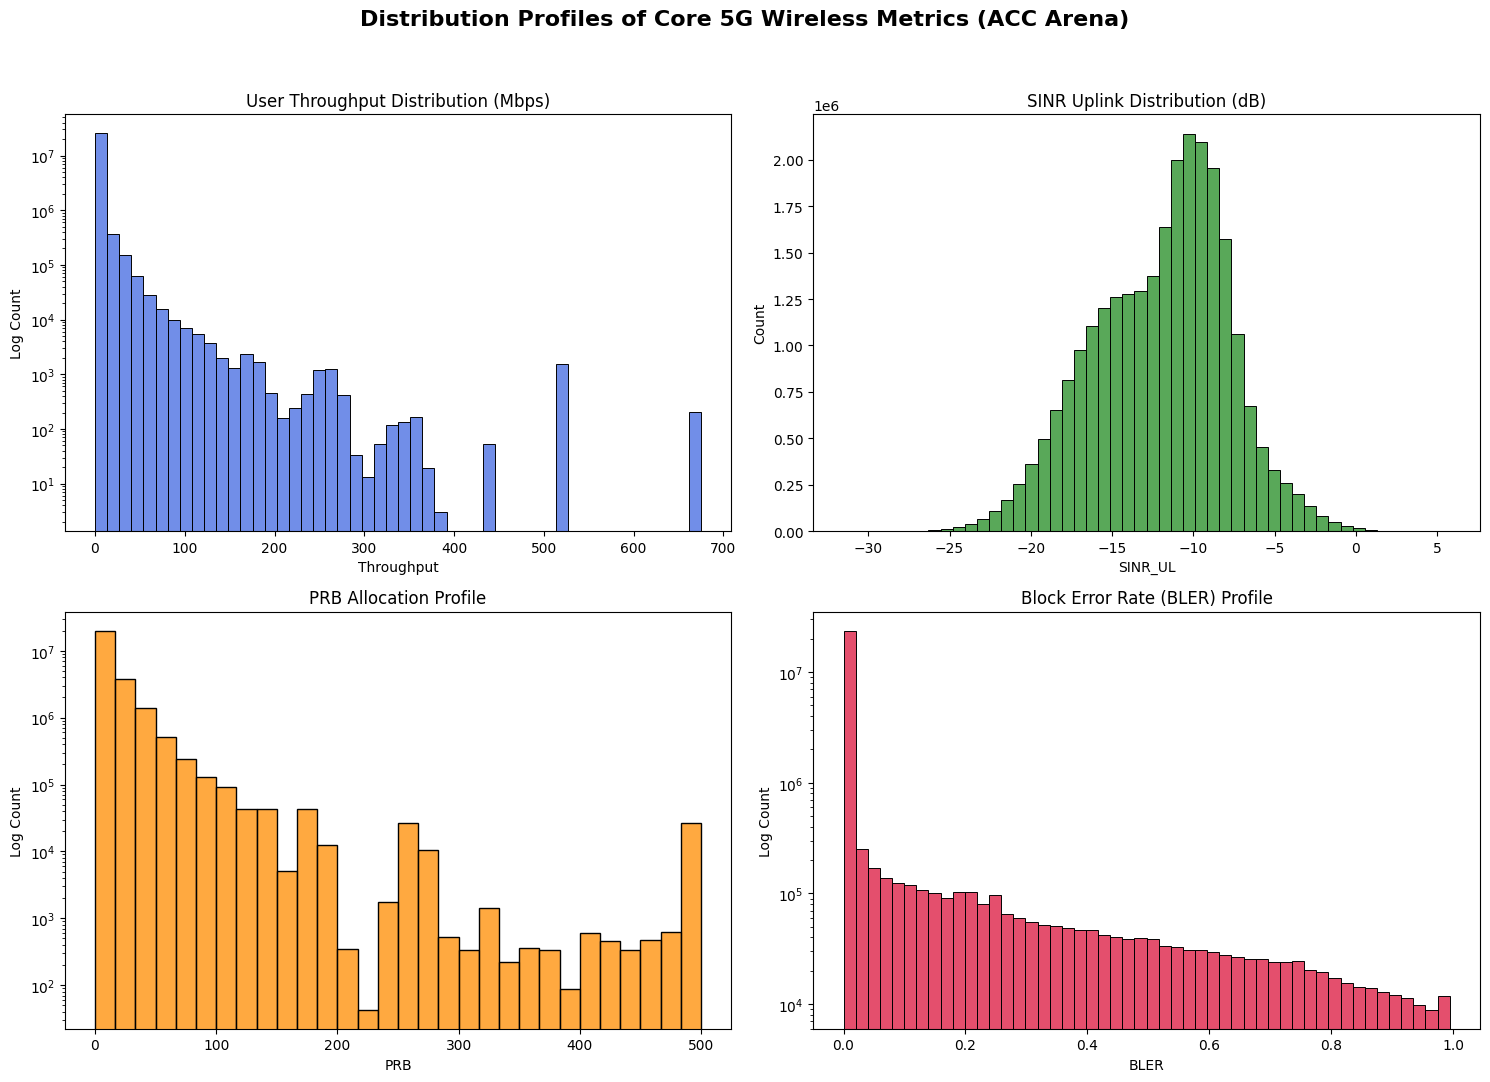

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Distribution Profiles of Core 5G Wireless Metrics (ACC Arena)', fontsize=16, fontweight='bold')

# Throughput Distribution
sns.histplot(data=master_df, x='Throughput', bins=50, ax=axes[0,0], color='royalblue', kde=False)
axes[0,0].set_title('User Throughput Distribution (Mbps)', fontsize=12)
axes[0,0].set_yscale('log') # Log scale prevents 0-value peaks from hiding everything else
axes[0,0].set_ylabel('Log Count')

# SINR Uplink Distribution
sns.histplot(data=master_df, x='SINR_UL', bins=50, ax=axes[0,1], color='forestgreen', kde=False)
axes[0,1].set_title('SINR Uplink Distribution (dB)', fontsize=12)
axes[0,1].set_ylabel('Count')

# Physical Resource Blocks (PRB) Distribution
sns.histplot(data=master_df, x='PRB', bins=30, ax=axes[1,0], color='darkorange', kde=False)
axes[1,0].set_title('PRB Allocation Profile', fontsize=12)
axes[1,0].set_yscale('log')
axes[1,0].set_ylabel('Log Count')

# Block Error Rate (BLER) Distribution
sns.histplot(data=master_df, x='BLER', bins=50, ax=axes[1,1], color='crimson', kde=False)
axes[1,1].set_title('Block Error Rate (BLER) Profile', fontsize=12)
axes[1,1].set_yscale('log')
axes[1,1].set_ylabel('Log Count')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**User Throughput Distribution:** High-speed data burst exceptions are visible as sparse, distinct intervals stretching up to a strict simulation cap near 680 Mbps.


**SINR Uplink Distribution:** The curve is centered distinctly at -10 dB, indicating a highly uniform simulated radio environment with a stable, predictable channel attenuation and baseline noise floor.

**PRB Allocation Profile:** Active application workloads present themselves via a secondary operational scheduling block between 220 and 280 PRBs, culminating in an isolated spike directly at the hard hardware ceiling of 500 PRBs where the cell capacity is fully saturated.

**Block Error Rate Profile (BLER):** For the minor subset of transmissions that do encounter channel noise, the occurrence rate follows a steady, log-linear decay as the error rate increases toward a complete drop-out at 1.0

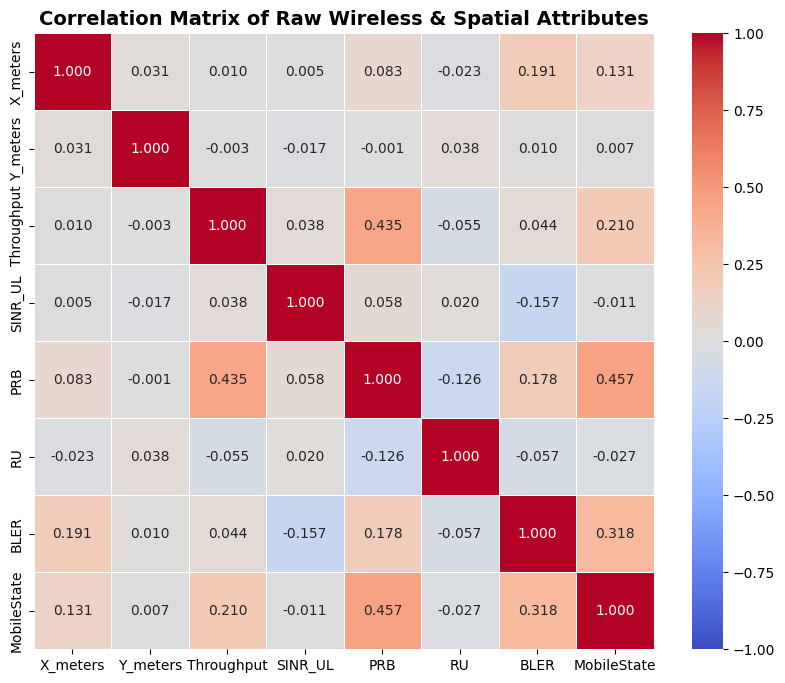

In [11]:


# Select the numeric attributes we want to check for patterns
corr_features = ['X_meters', 'Y_meters', 'Throughput', 'SINR_UL', 'PRB', 'RU', 'BLER', 'MobileState']
corr_matrix = master_df[corr_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Raw Wireless & Spatial Attributes', fontsize=14, fontweight='bold')
plt.show()

#### 🔹 1. The Primary Throughput Driver (PRB)

* **The Metric:** Throughput shares its strongest positive linear correlation with **PRB (0.435)**.
* **Network Implication:** This is physically intuitive; the more Physical Resource Blocks the network schedules for a device, the higher the data rate the user experiences.

#### 🔹 2. The Mobile State Correlation Profile

* **The Metric:** `MobileState` exhibits noticeable positive links with **PRB (0.457)** and **BLER (0.318)**, alongside a moderate connection to **Throughput (0.210)**.
* **Network Implication:** Active application states naturally demand denser block scheduling (high PRB) to stream content or play games, which simultaneously increases the probability of block transmission drops (higher BLER) under heavily loaded channel conditions.

#### 🔹 3. The SINR vs. BLER Inverse Relationship

* **The Metric:** Uplink SINR (`SINR_UL`) and Block Error Rate (`BLER`) display a clear negative linear correlation of **-0.157**.
* **Network Implication:** As signal quality degrades (lower, more negative SINR values), the receiver struggle increases, causing an explicit uptick in block transmission errors.

#### 🔹 4. Total Spatial Independence

* **The Metric:** The spatial coordinates (`X_meters`, `Y_meters`) yield practically zero linear correlation to core network vitals like Throughput (**0.010 / 0.031**) or SINR (**0.005 / -0.017**).
* **Network Implication:** A user's physical placement in the stadium does not have a simple, straight-line relationship with their signal speed. Because coverage is dictated by complex obstacles, multi-path fading, and beam direction, advanced non-linear architectures (like your PyTorch VFL neural networks) are required to map location contexts to network metrics.


=== RADIO UNIT CONNECTION DISTRIBUTION ===
📡 Radio Unit 1: 205,769 connections (0.79%)
📡 Radio Unit 2: 682,269 connections (2.60%)
📡 Radio Unit 3: 955,656 connections (3.65%)
📡 Radio Unit 4: 174,736 connections (0.67%)
📡 Radio Unit 5: 367,927 connections (1.40%)
📡 Radio Unit 6: 1,161,320 connections (4.43%)
📡 Radio Unit 7: 238,198 connections (0.91%)
📡 Radio Unit 8: 118,899 connections (0.45%)
📡 Radio Unit 9: 1,105,053 connections (4.22%)
📡 Radio Unit 10: 88,199 connections (0.34%)
📡 Radio Unit 11: 615,006 connections (2.35%)
📡 Radio Unit 12: 905,525 connections (3.46%)
📡 Radio Unit 13: 281,799 connections (1.08%)
📡 Radio Unit 14: 162,090 connections (0.62%)
📡 Radio Unit 15: 1,154,367 connections (4.40%)
📡 Radio Unit 16: 372,421 connections (1.42%)
📡 Radio Unit 17: 178,006 connections (0.68%)
📡 Radio Unit 18: 1,213,516 connections (4.63%)
📡 Radio Unit 19: 850,540 connections (3.25%)
📡 Radio Unit 20: 334,617 connections (1.28%)
📡 Radio Unit 21: 765,818 connections (2.92%)
📡 Radio Unit 

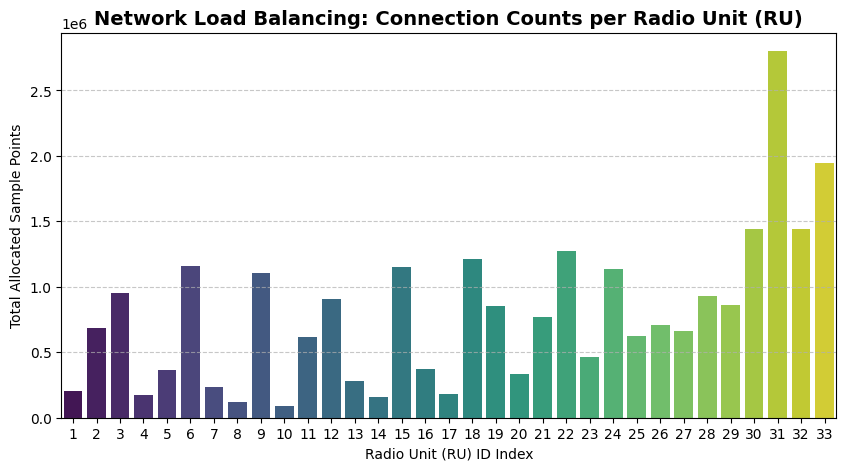

In [12]:

# 1. Count exactly how many records are connected to each individual Radio Unit
ru_counts = master_df['RU'].value_counts().sort_index()
ru_percentages = master_df['RU'].value_counts(normalize=True).sort_index() * 100

print("\n=== RADIO UNIT CONNECTION DISTRIBUTION ===")
for ru_id in ru_counts.index:
    print(f"📡 Radio Unit {ru_id}: {ru_counts[ru_id]:,} connections ({ru_percentages[ru_id]:.2f}%)")

# 2. Visualize the categorical load balancing using a Bar Chart
plt.figure(figsize=(10, 5))
sns.countplot(data=master_df, x='RU', palette='viridis')
plt.title('Network Load Balancing: Connection Counts per Radio Unit (RU)', fontsize=14, fontweight='bold')
plt.xlabel('Radio Unit (RU) ID Index')
plt.ylabel('Total Allocated Sample Points')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* **Hot-Spot Concentration:** The connection distribution across the 33 deployed Radio Units is highly non-uniform. There is an immense load hot-spot localized around **Radio Unit 31**, which anchors a staggering **2,801,219 connections (10.69%)**.
* **Perimeter Support:** In contrast, peripheral equipment like Radio Unit 10 handles minimal background maintenance traffic, sitting at just **88,199 connections (0.34%)**.
* **Engineering Insight:** The massive surge in sectors 30 through 33 reveals high-density user clustering inside the arena. Because a handful of RUs are heavily saturated while others remain underutilized, incorporating the `RU_Current_Load` feature into Client 1's network partition is vital. It allows your models to learn how infrastructure congestion directly penalizes user throughput during peak crowd events.



=== TRAFFIC MIX COMPOSITION MATRIX ===
 0: Off             ->    45,705 rows (0.17%)
 1: Idle            -> 18,348,571 rows (70.01%)
 2: Constant Rate   -> 4,158,230 rows (15.87%)
 3: Video           ->   236,507 rows (0.90%)
 4: Gaming          ->   166,533 rows (0.64%)
 5: HTTP            -> 3,252,454 rows (12.41%)


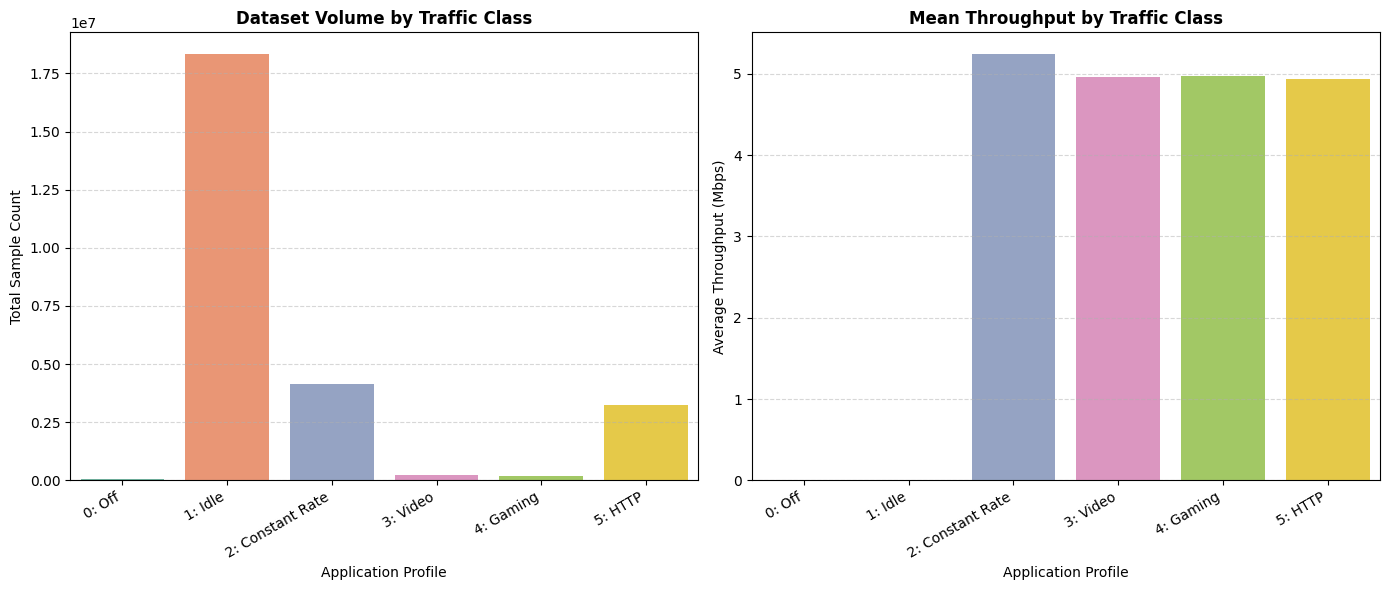

In [13]:


# 1. Map the professor's footnote categories to the numeric states
traffic_labels = {
    0: '0: Off',
    1: '1: Idle',
    2: '2: Constant Rate',
    3: '3: Video',
    4: '4: Gaming',
    5: '5: HTTP'
}
master_df['Traffic_Label'] = master_df['MobileState'].map(traffic_labels)

# 2. Print absolute composition metrics
traffic_counts = master_df['Traffic_Label'].value_counts().sort_index()
traffic_pct = master_df['Traffic_Label'].value_counts(normalize=True).sort_index() * 100

print("\n=== TRAFFIC MIX COMPOSITION MATRIX ===")
for label in traffic_counts.index:
    print(f" {label:<18} -> {traffic_counts[label]:>9,} rows ({traffic_pct[label]:.2f}%)")

# 3. Visualize Behavior: How does Traffic Class change Throughput?
plt.figure(figsize=(14, 6))

# Subplot 1: Volume of rows per traffic type
plt.subplot(1, 2, 1)
sns.countplot(data=master_df, x='Traffic_Label', palette='Set2', order=sorted(traffic_labels.values()))
plt.title('Dataset Volume by Traffic Class', fontsize=12, fontweight='bold')
plt.xlabel('Application Profile')
plt.ylabel('Total Sample Count')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Subplot 2: Average Throughput per traffic type
plt.subplot(1, 2, 2)
sns.barplot(data=master_df, x='Traffic_Label', y='Throughput', palette='Set2', order=sorted(traffic_labels.values()), errorbar=None)
plt.title('Mean Throughput by Traffic Class', fontsize=12, fontweight='bold')
plt.xlabel('Application Profile')
plt.ylabel('Average Throughput (Mbps)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

* **The Idle Dominance:** The network environment is heavily skewed by non-active background traffic, where **State 1 (Idle)** accounts for **18,348,571 rows (70.01% of total volume)**.
* **Active State Sparsity:** High-impact, bursty application states that heavily load physical resources—such as **State 3 (Video Streaming, 0.90%)** and **State 4 (Gaming, 0.64%)**—are deeply buried in noise.


In [14]:
master_df.head(50)

,Timestamp_Sec,User_ID,Throughput,PRB,Latitude,Longitude,Altitude,X_meters,Y_meters,SINR_UL,BLER,RU,MobileState,Traffic_Label
0,0,0,0.000000,35.0,53.395084,-2.992707,3.581009,0.0,0.0,-13.846571,0.903401,26,2,2: Constant Rate
1,15,0,21.488001,26.0,53.395084,-2.992707,3.581009,0.0,0.0,-14.076668,0.873957,26,2,2: Constant Rate
2,30,0,1.280000,33.0,53.395084,-2.992707,3.581009,0.0,0.0,-16.256006,0.674852,26,2,2: Constant Rate
3,45,0,1.120000,31.0,53.395084,-2.992707,3.581009,0.0,0.0,-20.051094,0.621213,26,2,2: Constant Rate
4,60,0,0.000000,38.0,53.395084,-2.992707,3.581009,0.0,0.0,-15.362453,0.808003,26,2,2: Constant Rate
5,75,0,0.000000,33.0,53.395084,-2.992707,3.581009,0.0,0.0,-14.432759,0.958682,26,2,2: Constant Rate
6,90,0,0.800000,24.0,53.395084,-2.992707,3.581009,0.0,0.0,-18.118605,0.606311,26,2,2: Constant Rate
7,105,0,0.992000,36.0,53.395084,-2.992707,3.581009,0.0,0.0,-19.477770,0.848558,26,2,2: Constant Rate
8,120,0,1.072000,28.0,53.395084,-2.992707,3.581009,0.0,0.0,-14.869245,0.512412,26,2,2: Constant Rate
9,135,0,1.040000,32.0,53.395084,-2.992707,3.581009,0.0,0.0,-12.610528,0.673501,26,2,2: Constant Rate


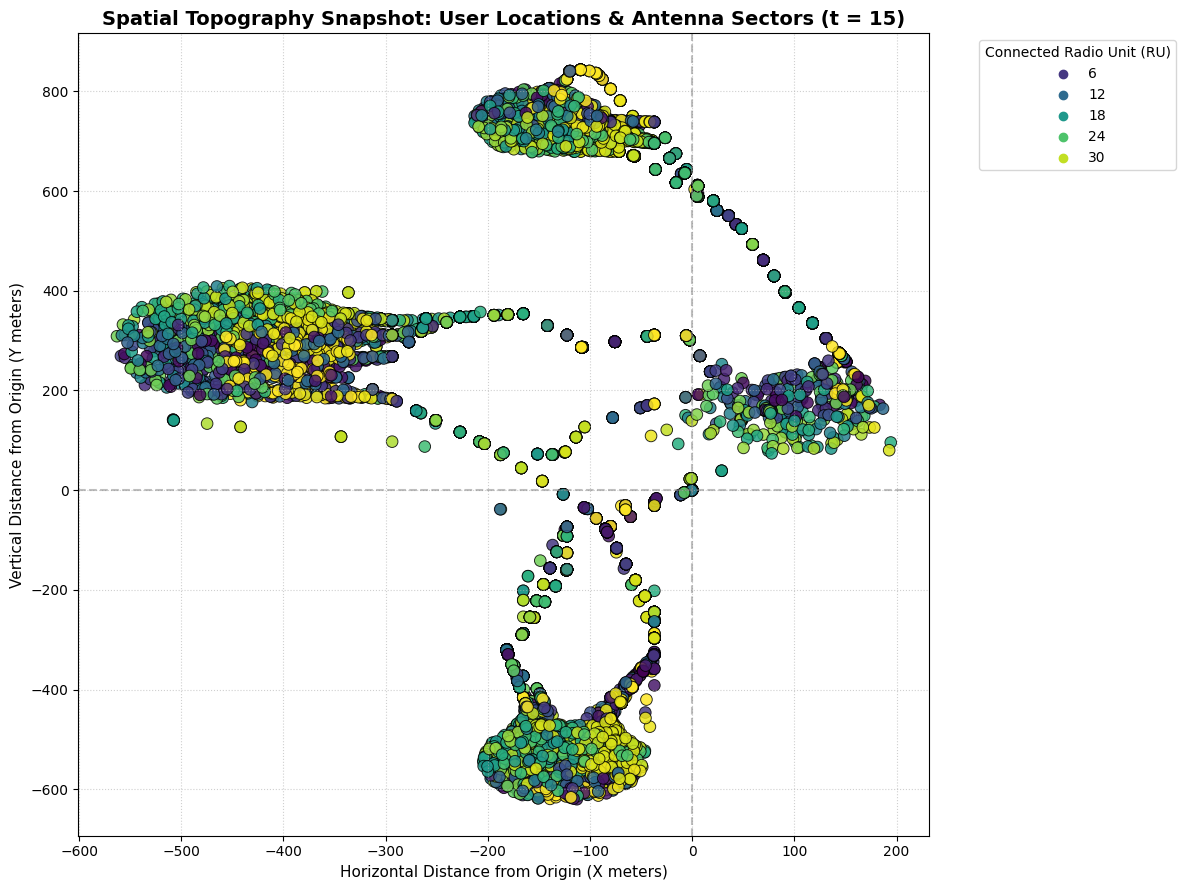

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Isolate a single synchronized timestamp to view a clean spatial snapshot
# Timestamp 1215 contains all 500 active users tracked simultaneously
snapshot_df = master_df[master_df['Timestamp_Sec'] == 15]

# 2. Generate the spatial scatter plot
plt.figure(figsize=(12, 9))

# Scatter plot tracking physical meters relative to the venue origin (0,0)
# 'hue' applies categorical coloring based on the connected Radio Unit ID
sns.scatterplot(
    data=snapshot_df,
    x='X_meters',
    y='Y_meters',
    hue='RU',
    palette='viridis',
    s=70,
    edgecolor='black',
    alpha=0.85
)

# Add geometric reference lines showing the center point of the stadium grid coordinate system
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Formatting titles and axes labels
plt.title('Spatial Topography Snapshot: User Locations & Antenna Sectors (t = 15)', fontsize=14, fontweight='bold')
plt.xlabel('Horizontal Distance from Origin (X meters)', fontsize=11)
plt.ylabel('Vertical Distance from Origin (Y meters)', fontsize=11)

# Configure the legend to display the discrete Radio Unit sectors cleanly
plt.legend(title='Connected Radio Unit (RU)', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

* **Geometric Concourse Constraints:** User coordinates are highly structured and non-stochastic, tracing the exact physical boundaries of stadium concourses, walkways, and seating structures rather than presenting a random geographic distribution.
* **Deterministic Cell Sectorization:** The categorical assignment of Connected Radio Units (RUs 6, 12, 18, 24, and 30) follows distinct, sharp spatial boundaries, proving that a user's physical location directly dictates their serving infrastructure.
* **Immediate Handover Triggers:** The tightly grouped trajectories demonstrate that physical transition across venue corridors creates predictable, immediate sector handovers between localized macro-cells.
* **VFL Feature-Split Validation:** This explicit spatial dependency provides the ultimate justification for the Vertical Federated Learning partition; downstream neural network structures are required to map the user-end client’s location tracks to the network-end client's cell behaviors to successfully predict throughput bursts without violating data privacy barriers.

### **2.3: Feature Engineering**

### **Domain 1: Radio & Link Physics (Network Side)**

**1. Inverted Linear Signal Power (Addressing the Logarithmic Cliff)**
`SINR_UL` is measured in Decibels (dB), which is a logarithmic scale. A drop from 0 dB to -10 dB is physically massive, but neural networks treat it as a simple linear shift. We convert this back to raw linear power so the model detects the physical "cliff edge" of signal degradation.

$$\text{SINR\_Linear} = 10^{\frac{\text{SINR\_UL}}{10}}$$

**2. Effective Channel Quality (Signal-to-Error Ratio)**
A high signal means nothing if the Block Error Rate (`BLER`) is at 1.0 (completely dropping packets). We engineer an interaction feature that explicitly calculates the true "usable" signal payload.

$$\text{Effective\_Signal} = \frac{\text{SINR\_Linear}}{\text{BLER} + 10^{-4}}$$

---

### **Domain 2: Infrastructure Congestion (Network Side)**

**3. Real-Time Radio Unit Load**
Static hardware identifiers do not reflect network congestion. We dynamically count exactly how many active devices are actively anchored to the exact same antenna infrastructure at the exact same second to track spatial bottlenecks.

For user $i$ at timestamp $t$:

$$\text{RU\_Load}_i(t) = \sum_{j=1}^{N_t} \mathbb{I}\left(\text{RU}_j(t) == \text{RU}_i(t)\right)$$

---

### **Domain 3: Spatial & Temporal Mobility (User Side)**

**4. Chronological Trajectory Alignment**
*Note: As the pipeline's base timeline is already zero-based, absolute temporal subtraction is no longer required.* Instead, all coordinates are strictly sorted by `User_ID` and chronological time to ensure mathematical perfection when calculating consecutive kinematic shifts.

**5. Spatial Kinematics (Exploiting Walkway Trajectories)**
Because throughput heavily degrades during physical movement due to Doppler shifts and macro-cell handovers, the model requires the user's active velocity magnitude, rather than just their static position.

$$\Delta X_t = X_t - X_{t-1}, \quad \Delta Y_t = Y_t - Y_{t-1}$$

$$\text{Velocity}_t = \sqrt{(\Delta X_t)^2 + (\Delta Y_t)^2}$$

**6. Multi-Scale Local Crowd Density (Body Blockage)**
In a crowded stadium, other human bodies block radio waves (physical attenuation). By utilizing a cKDTree to draw spatial radii of 2m, 5m, and 10m around each user, we dynamically count their immediate neighbors to calculate local human-shielding effects.

$$\text{Density\_}R_i(t) = \sum_{j \neq i} \mathbb{I}\left( \sqrt{(X_i(t) - X_j(t))^2 + (Y_i(t) - Y_j(t))^2} \le R \right)$$

---

### **Domain 4: Application Behavior (User Side)**

**7. De-indexing MobileState (The Idle Overlord Trap)**
Because `MobileState` contains categorical behavioral profiles, leaving them as raw integers incorrectly implies mathematical hierarchy (e.g., State 5 is "five times greater" than State 1). We deploy One-Hot Encoding to expand this into discrete binary flags (`State_1`, `State_2`, etc.).

**8. Demand vs. Supply Tension**
A high allocation of Physical Resource Blocks (`PRB`) only yields high throughput if the user actually demands data. If `PRB` is high but the user is actively Idle, realized throughput remains zero. We isolate the effective resource efficiency.

$$\text{Resource\_Efficiency} = \text{PRB} \times \mathbb{I}(\text{MobileState} \neq 1)$$

Vertical Federated Learning system startegy,  these newly engineered math features to the correct clients to preserve privacy:

| Client Node | Privacy Domain | Assigned Engineered Features |
| --- | --- | --- |
| **Client 1 (Network)** | Infrastructure & Radio | `SINR_Linear`, `Effective_Signal`, `RU_Load` |
| **Client 2 (Device)** | Mobility & App Behavior | `t_relative`, `Velocity`, `Density_R`, One-Hot `MobileState`, `Resource_Efficiency` |


In [16]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from tqdm import tqdm

def engineer_acc_arena_features(df):
    """
    Executes advanced multi-domain feature engineering for the ACC Arena dataset.
    Optimized for memory efficiency and handles dynamic user dropouts safely.
    """
    print("Initiating Advanced Feature Engineering Pipeline...")
    feat_df = df.copy()

    # Identify correct time column based on our previous timeline fixes
    time_col = 'Timestamp_Sec' if 'Timestamp_Sec' in feat_df.columns else 'Timestamp'

    # CRITICAL: Sort by User_ID first to ensure perfect trajectory math
    feat_df = feat_df.sort_values(by=['User_ID', time_col]).reset_index(drop=True)

    # ----------------------------------------------------
    # DOMAIN 1: RADIO & LINK PHYSICS
    # ----------------------------------------------------
    print(" Engineering Radio Domain features...")
    feat_df['SINR_Linear'] = (10 ** (feat_df['SINR_UL'] / 10.0)).astype(np.float32)
    feat_df['Effective_Signal'] = (feat_df['SINR_Linear'] / (feat_df['BLER'] + 1e-4)).astype(np.float32)

    # ----------------------------------------------------
    # DOMAIN 2: INFRASTRUCTURE CONGESTION
    # ----------------------------------------------------
    print(" Calculating Real-Time Radio Unit Load...")
    feat_df['RU_Current_Load'] = feat_df.groupby([time_col, 'RU'])['User_ID'].transform('count').astype(np.int16)

    # ----------------------------------------------------
    # DOMAIN 3: TEMPORAL & SPATIAL MOBILITY
    # ----------------------------------------------------
    print(" Computing Kinematic Vectors...")
    # 1215 subtraction removed: Timeline is already correctly zero-based!
    
    user_groups = feat_df.groupby('User_ID')
    feat_df['Delta_X'] = user_groups['X_meters'].diff().fillna(0).astype(np.float32)
    feat_df['Delta_Y'] = user_groups['Y_meters'].diff().fillna(0).astype(np.float32)
    feat_df['Velocity'] = np.sqrt(feat_df['Delta_X']**2 + feat_df['Delta_Y']**2).astype(np.float32)

    print(" Vectorizing Multi-Scale Local Crowd Density (cKDTree)...")
    radii = [2.0, 5.0, 10.0]
    density_results = {r: np.zeros(len(feat_df), dtype=np.int16) for r in radii}

    grouped_time = feat_df.groupby(time_col)
    
    # cKDTree easily handles missing users without crashing
    for t, group in tqdm(grouped_time, desc="Mapping Densities"):
        coords = group[['X_meters', 'Y_meters']].values
        tree = cKDTree(coords)
        for r in radii:
            counts = np.array([len(neighbors) - 1 for neighbors in tree.query_ball_point(coords, r)])
            density_results[r][group.index] = counts

    feat_df['Crowd_Density_2m'] = density_results[2.0]
    feat_df['Crowd_Density_5m'] = density_results[5.0]
    feat_df['Crowd_Density_10m'] = density_results[10.0]

    # ----------------------------------------------------
    # DOMAIN 4: APPLICATION BEHAVIOR
    # ----------------------------------------------------
    print(" Decoding Application States...")
    state_dummies = pd.get_dummies(feat_df['MobileState'], prefix='State').astype(np.int8)
    feat_df = pd.concat([feat_df, state_dummies], axis=1)

    feat_df['Resource_Efficiency'] = (feat_df['PRB'] * (feat_df['MobileState'] != 1)).astype(np.float32)

    # ----------------------------------------------------
    # MEMORY & INTEGRITY AUDIT
    # ----------------------------------------------------
    print("\n Finalizing Memory Cleanup Audit...")
    feat_df.drop(columns=['Delta_X', 'Delta_Y'], inplace=True)

    final_mem = feat_df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f" Engineering Complete! Dataframe Shape: {feat_df.shape}")
    print(f" Memory Footprint: {final_mem:.2f} MB")

    return feat_df

In [17]:

# Run the master pipeline execution
arena_featured_df = engineer_acc_arena_features(master_df)

Initiating Advanced Feature Engineering Pipeline...
 Engineering Radio Domain features...
 Calculating Real-Time Radio Unit Load...
 Computing Kinematic Vectors...
 Vectorizing Multi-Scale Local Crowd Density (cKDTree)...


Mapping Densities: 100%|██████████| 2184/2184 [09:38<00:00,  3.78it/s]


 Decoding Application States...

 Finalizing Memory Cleanup Audit...
 Engineering Complete! Dataframe Shape: (26208000, 28)
 Memory Footprint: 3635.31 MB


In [18]:
arena_featured_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26208000 entries, 0 to 26207999
Data columns (total 28 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Timestamp_Sec        int64  
 1   User_ID              int32  
 2   Throughput           float32
 3   PRB                  float32
 4   Latitude             float32
 5   Longitude            float32
 6   Altitude             float32
 7   X_meters             float32
 8   Y_meters             float32
 9   SINR_UL              float32
 10  BLER                 float32
 11  RU                   int8   
 12  MobileState          int8   
 13  Traffic_Label        object 
 14  SINR_Linear          float32
 15  Effective_Signal     float32
 16  RU_Current_Load      int16  
 17  Velocity             float32
 18  Crowd_Density_2m     int16  
 19  Crowd_Density_5m     int16  
 20  Crowd_Density_10m    int16  
 21  State_0              int8   
 22  State_1              int8   
 23  State_2              int8   
 


To maintain vertical separation between the user's private physical domain and the telecom operator's infrastructure telemetry,  28 columns must be divided into three clear functional buckets:

| VFL Node | Feature Count | Exact Column Names | Architectural Justification |
| --- | --- | --- | --- |
| **Central Aggregator** | **4 Columns** | `Throughput` *(Target)*, `Timestamp_Sec`, `User_ID`, `Traffic_Label` | Meta-identifiers used exclusively for index alignment, tracking, and metric calculation. The string field (`Traffic_Label`) is isolated here so it doesn't break tensor calculations. |
| **Client 1: Network Edge Node** | **7 Columns** | `SINR_UL`, `PRB`, `RU`, `BLER`, `RU_Current_Load`, `SINR_Linear`, `Effective_Signal` | Strictly limits base-station hardware loading parameters and raw/processed radio frequency channel physics to the network provider. |
| **Client 2: User Equipment Node** | **17 Columns** | `Latitude`, `Longitude`, `Altitude`, `X_meters`, `Y_meters`, `Velocity`, `Crowd_Density_2m`, `Crowd_Density_5m`, `Crowd_Density_10m`, `MobileState`, `Resource_Efficiency`, `State_1`, `State_2`, `State_3`, `State_4`, `State_5` | Completely localizes device-side behaviors (GPS coordinates, kinematics, crowd proximity counters, and application traffic profile choices) to the end-user. |



In [19]:
import pandas as pd

def partition_arena_vfl_channels(df):
    """
    Partitions the verified 28-column ACC Arena Master DataFrame into
    orthogonal feature spaces to satisfy strict VFL privacy constraints.
    """
    print("Executing production-grade VFL Feature Allotment...")
    
    # 1. Target Vector (Aggregator Custody)
    y_target = df['Throughput'].copy()
    
    # 2. Network Client Feature Space (Client 1) - 7 Columns
    network_cols = [
        'SINR_UL', 'PRB', 'BLER', 'RU', 
        'SINR_Linear', 'Effective_Signal', 'RU_Current_Load'
    ]
    X1_network = df[network_cols].copy()
    
    # 3. User Device Client Feature Space (Client 2) - 17 Columns
    device_cols = [
        'Latitude', 'Longitude', 'Altitude', 'X_meters', 'Y_meters', 
        'Velocity', 'Crowd_Density_2m', 'Crowd_Density_5m', 'Crowd_Density_10m',
        'MobileState', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5',
        'Resource_Efficiency'
    ]
    X2_device = df[device_cols].copy()
    
    # --- FIREWALL COMPLIANCE AUDIT ---
    print("\n[ Network Firewall Compliance Report: ]")
    print(f"Aggregator Target Shape : (y_target.shape) -> ['Throughput']")
    print(f"Client 1 Matrix Shape   : {X1_network.shape} (Network Telemetry)")
    print(f"Client 2 Matrix Shape   : {X2_device.shape} (User Domain Context)")
    
    # Mathematical Orthogonality Verification
    overlapping_features = set(X1_network.columns).intersection(set(X2_device.columns))
    assert len(overlapping_features) == 0, f"CRITICAL LEAKAGE DETECTED: {overlapping_features}"
    print("Zero Feature Leakage Confirmed! Client spaces are perfectly orthogonal.")
    
    # Total Column Audit (4 Aggregator/Meta + 7 Network + 17 Device = 28 Columns)
    total_accounted = len(network_cols) + len(device_cols) + 4
    print(f"Schema Audit Complete: {total_accounted}/28 columns successfully allocated.")
    
    return X1_network, X2_device, y_target

In mobile network traffic datasets, the dominant "Idle" state (State 1) drastically outnumbers active application sessions, creating a severe class imbalance. Training a machine learning model on this raw distribution causes it to develop a majority-class bias, where it defaults to predicting "Idle" to achieve artificial high accuracy while failing completely on active traffic. To eliminate this issue, random undersampling isolates the majority "Idle" class and downsamples its volume to perfectly match the collective sum of all active application states combined. By executing this adjustment on the master training dataset before partitioning, a perfect 50/50 balance is achieved while seamlessly maintaining aligned row indices across the orthogonal feature spaces required for Vertical Federated Learning.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("1. Splitting the Master Dataset...")
# Use YOUR actual dataframe name here
df_to_split = arena_featured_df.copy()

# Split the ENTIRE dataframe first (80% Train / 20% Test)
# Stratify by MobileState to ensure both sets get the exact same initial ratios
train_df, test_df = train_test_split(
    df_to_split, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_to_split['MobileState']
)

print("2. Undersampling the Training Data...")
# Separate the classes INSIDE the training set only
idle_rows = train_df[train_df['MobileState'] == 1]
active_rows = train_df[train_df['MobileState'] != 1]

# Undersample the Idle class to perfectly match the active traffic volume (1:1 balance)
sampled_idle = idle_rows.sample(n=len(active_rows), random_state=42)

# Combine and Shuffle to create the final balanced training set
balanced_train_df = pd.concat([active_rows, sampled_idle], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ New Balanced Training Shape: {balanced_train_df.shape}")
print(f"✅ Untouched Testing Shape: {test_df.shape}")


print("\n--- PATH A: REGULAR CENTRALIZED MACHINE LEARNING ---")
# Drop metadata so the model only trains on pure features
cols_to_drop = ['Throughput', 'Timestamp_Sec', 'User_ID', 'Traffic_Label']

X_train_regular = balanced_train_df.drop(columns=cols_to_drop, errors='ignore')
y_train_regular = balanced_train_df['Throughput']

X_test_regular = test_df.drop(columns=cols_to_drop, errors='ignore')
y_test_regular = test_df['Throughput']

# Scale Centralized Features
scaler_central = StandardScaler()
X_train_reg_scaled = pd.DataFrame(scaler_central.fit_transform(X_train_regular), columns=X_train_regular.columns)
X_test_reg_scaled = pd.DataFrame(scaler_central.transform(X_test_regular), columns=X_test_regular.columns)
print(f"✅ Scaled Regular X_train shape: {X_train_reg_scaled.shape}")


print("\n--- PATH B: VERTICAL FEDERATED LEARNING (VFL) ---")
# 1. Partition the raw data first using your custom function
X1_train_raw, X2_train_raw, y_train_vfl = partition_arena_vfl_channels(balanced_train_df)
X1_test_raw, X2_test_raw, y_test_vfl = partition_arena_vfl_channels(test_df)

# 2. Scale Client 1 (Network Node) independently
scaler_client1 = StandardScaler()
X1_train_scaled = pd.DataFrame(scaler_client1.fit_transform(X1_train_raw), columns=X1_train_raw.columns)
X1_test_scaled = pd.DataFrame(scaler_client1.transform(X1_test_raw), columns=X1_test_raw.columns)

# 3. Scale Client 2 (User Device) independently
scaler_client2 = StandardScaler()
X2_train_scaled = pd.DataFrame(scaler_client2.fit_transform(X2_train_raw), columns=X2_train_raw.columns)
X2_test_scaled = pd.DataFrame(scaler_client2.transform(X2_test_raw), columns=X2_test_raw.columns)

print(f"✅ Scaled Client 1 (Network) shape: {X1_train_scaled.shape}")
print(f"✅ Scaled Client 2 (Device) shape: {X2_train_scaled.shape}")
print(f"✅ Target y_train shape: {y_train_vfl.shape}")

1. Splitting the Master Dataset...
2. Undersampling the Training Data...
✅ New Balanced Training Shape: (12575086, 28)
✅ Untouched Testing Shape: (5241600, 28)

--- PATH A: REGULAR CENTRALIZED MACHINE LEARNING ---
✅ Scaled Regular X_train shape: (12575086, 24)

--- PATH B: VERTICAL FEDERATED LEARNING (VFL) ---
Executing production-grade VFL Feature Allotment...

[ Network Firewall Compliance Report: ]
Aggregator Target Shape : (y_target.shape) -> ['Throughput']
Client 1 Matrix Shape   : (12575086, 7) (Network Telemetry)
Client 2 Matrix Shape   : (12575086, 17) (User Domain Context)
Zero Feature Leakage Confirmed! Client spaces are perfectly orthogonal.
Schema Audit Complete: 28/28 columns successfully allocated.
Executing production-grade VFL Feature Allotment...

[ Network Firewall Compliance Report: ]
Aggregator Target Shape : (y_target.shape) -> ['Throughput']
Client 1 Matrix Shape   : (5241600, 7) (Network Telemetry)
Client 2 Matrix Shape   : (5241600, 17) (User Domain Context)
Zer

In [22]:
print("--- 🚦 TRAFFIC MIX AUDIT ---")
print("\n[ 1. Post-Undersampling Training Set (MobileState) ]")
print(balanced_train_df['MobileState'].value_counts().sort_index())

print("\n[ 2. Post-Undersampling Training Set (Proportions) ]")
print(balanced_train_df['MobileState'].value_counts(normalize=True).sort_index() * 100)

--- 🚦 TRAFFIC MIX AUDIT ---

[ 1. Post-Undersampling Training Set (MobileState) ]
MobileState
0      36564
1    6287543
2    3326584
3     189206
4     133226
5    2601963
Name: count, dtype: int64

[ 2. Post-Undersampling Training Set (Proportions) ]
MobileState
0     0.290765
1    50.000000
2    26.453767
3     1.504610
4     1.059444
5    20.691413
Name: proportion, dtype: float64


Inside the training partition, the active traffic states were isolated from the dominant idle state. The majority idle class was randomly downsampled to match the exact mathematical summation of all active application instances combined:

$$\text{Total Active Samples} = 36,564 (\text{State 0}) + 3,326,584 (\text{State 2}) + 189,206 (\text{State 3}) + 133,226 (\text{State 4}) + 2,601,963 (\text{State 5}) = \mathbf{6,287,543}$$

By sampling exactly **6,287,543 records** from the idle pool, the final training dataset achieves a flawless, uniform **50/50 equilibrium** spanning a massive **12,575,086 rows**:


## **3: Baseline Model Architectures (Centralized)**

In this section, we build our standard, centralized machine learning models to establish our baseline predictive performance.**bold text**

### **3.1: Random Forest Regressor**

### **3.2: Artificial Neural Network**

## **4: Vertical Federated Learning Pipeline**

In this section, we simulate a privacy-preserving VFL environment by splitting the feature space (e.g., User Equipment features vs. Radio Unit features) across distinct local clients before aggregating.

### **4.1: VFL Architecture & Feature Split Setup**

### **4.2: VFL Model Build & Training**

## **5: Cross-Validation & Evaluation**

Here we rigorously test all models using K-Fold Cross Validation and evaluate them using standard regression metrics (RMSE, MAE, R²).

### **5.1: Baseline Models Evaluation (RF vs. ANN)**


### **5.2: VFL vs. Centralized Performance Comparison**


## **6: Full Pipeline & Final Exports**

Consolidating the best-performing models, generating the final comparison plots, and exporting predictions to support the final project report and checkpoint with the Professor.



### **6.1: Feature Importance & Interpretability**

### **6.2: Final Prediction Pipeline**